### **Decision Tree Regression Implementation**

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Step 1: Generate a synthetic dataset (noisy sine wave)
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(200, 1), axis=0)
y = np.sin(X).ravel() + 0.1 * rng.randn(200)

In [3]:
# Step 2: Split data into training and test structures (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Step 3: Define hyperparameter space for Grid Search Optimization
param_grid = {
    'max_depth': [2, 4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [5]:
# Step 4: Initialize the model and search framework
base_regressor = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=base_regressor, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

In [6]:
# Step 5: Fit the model to find optimal hyperparameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [7]:
# Step 6: Generate predictions on unseen test data
y_pred = best_model.predict(X_test)

In [8]:
# Step 7: Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

Optimal Hyperparameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5}
Mean Squared Error (MSE): 0.0166
R-squared Score (R²): 0.9689


#### **Visualizing the Tree**

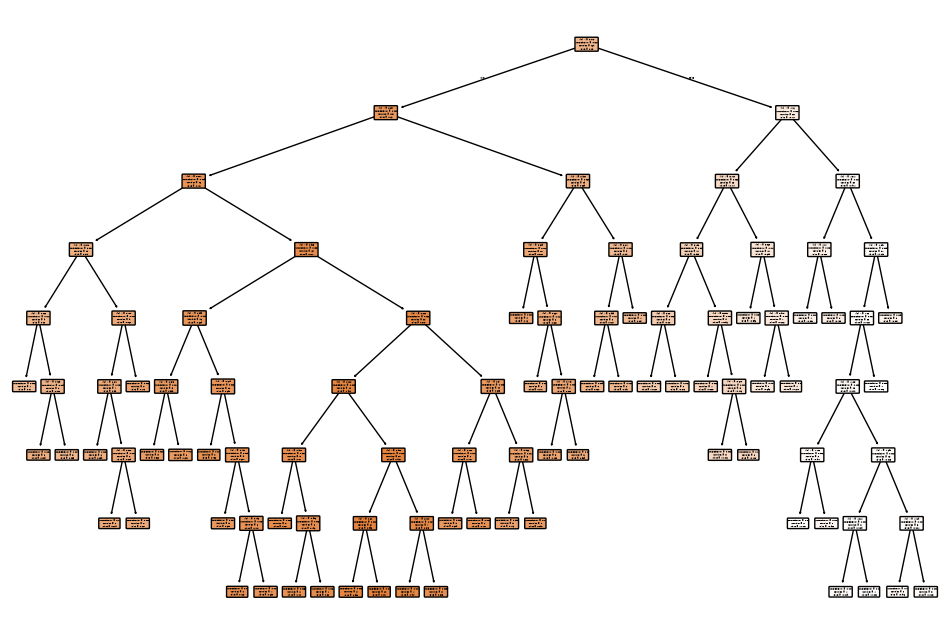

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plot_tree(best_model, filled=True, rounded=True)

plt.show()

#### **Hyperparameter Tuning**

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

params = {
    "max_depth": [3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    DecisionTreeRegressor(),
    params,
    cv=5
)

grid.fit(X, y)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}


#### **Feature Importance**

Decision Trees can estimate feature importance.

In [20]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Set random seed for reproducible "random" data
np.random.seed(42)

# 1. Generate 6 samples with 5 features each using random data
# We create a random matrix of size (6 samples, 5 features)
X = np.random.randint(low=1, high=20, size=(6, 5))

# 2. Define a target variable y 
# For demonstration, y is heavily dependent on Feature 0 and Feature 2
y = (X[:, 0] * 2) + (X[:, 2] ** 2)

print("--- Generated X Array (6 samples, 5 features) ---")
print(X)
print("\n--- Generated Target Vector y ---")
print(y)

# 3. Initialize and train the Decision Tree Regressor
model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X, y)

# 4. Generate feature names dynamically based on the 5 columns
feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# 5. Print Feature Importance to the console
print("\n--- Feature Importance ---")
for feature, importance in zip(feature_names, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")


--- Generated X Array (6 samples, 5 features) ---
[[ 7 15 11  8  7]
 [19 11 11  4  8]
 [ 3  2 12  6  2]
 [ 1 12 12 17 10]
 [16 15 15 19 12]
 [ 3  5 19  7  9]]

--- Generated Target Vector y ---
[135 159 150 146 257 367]

--- Feature Importance ---
Feature 0: 0.0000
Feature 1: 0.1475
Feature 2: 0.8525
Feature 3: 0.0000
Feature 4: 0.0000
